# Feature Engineering — 03

**Objetivo:** convertir el dataset curado en una matriz de features lista para modelar:
descarte de columnas sin señal, target logarítmico (`log_precio_usd`), codificación
ordinal de categóricas por mediana de precio e imputación por mediana. Cierra con el
split reproducible train / val / test (80 / 10 / 10).

**Entrada:** `data/processed/propiedades_argenprop_curado.csv`
**Salida:** `data/processed/propiedades_argenprop_features.csv`


## Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Bootstrap para importar `real_estate` (layout src/) sin instalar el paquete.
SRC_DIR = Path.cwd().parent / "src"
if not SRC_DIR.exists():
    SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from real_estate.features import pipeline as pl  # noqa: E402

RUTA_CURADO = Path("../data/processed/propiedades_argenprop_curado.csv")
RUTA_FEATURES = Path("../data/processed/propiedades_argenprop_features.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

## 1. Construcción de la matriz de features

La función `pl.construir_features` orquesta las cuatro etapas definidas en
`src/real_estate/features/transformations.py`:

1. **Selección de columnas:** descarta las sin señal (cobertura < 3 %, texto libre,
   identificadores y redundancias de moneda).
2. **Target logarítmico:** filtra precios inválidos (< `PRECIO_MINIMO_USD` — incluye
   los artefactos de scraping con precio 1 USD) y crea `log_precio_usd`.
3. **Codificación ordinal:** `barrio` y `tipo_propiedad` se codifican por el orden de
   la mediana de precio (apto para árboles; las categorías nuevas o NaN van a -1).
4. **Imputación por mediana:** rellena las numéricas con faltantes usando la mediana.


In [2]:
df_curado = pd.read_csv(RUTA_CURADO, low_memory=False)
print(f"Curado: {df_curado.shape[0]:,} filas x {df_curado.shape[1]} columnas")

matriz = pl.construir_features(df_curado)

Curado: 2,005 filas x 32 columnas

FEATURE ENGINEERING

Filas iniciales: 2,005 | Columnas: 32
Tras seleccionar columnas: 15 columnas
Descartadas 6 filas con precio inválido (< 1,000 USD).
barrio                         -> 44 categorías codificadas
tipo_propiedad                 -> 7 categorías codificadas
Imputadas por mediana: ['ambientes', 'antiguedad', 'banos', 'dormitorios', 'expensas_usd', 'superficie_cubierta']

Filas finales: 1,999 | Columnas: 16
Faltantes restantes: 0


## 2. La matriz de features

In [3]:
pl.mostrar_features(matriz)


MATRIZ DE FEATURES

Filas: 1,999 | Columnas: 16

Primeras filas:
   superficie_cubierta  ambientes  dormitorios  banos  antiguedad  precio_usd  expensas_usd  expensas_informado  superficie_cubierta_informado  ambientes_informado  dormitorios_informado  banos_informado  antiguedad_informado  log_precio_usd  barrio_ordinal  tipo_propiedad_ordinal
0                300.0        5.0          3.0    1.0        17.0   2400000.0   1428.571429                   1                              1                    1                      1                0                     1       14.690979              37                       1
1                 90.0        2.0          1.0    1.0        40.0    175000.0    162.337662                   1                              1                    1                      1                0                     1       12.072541              37                       1
2                171.0        4.0          3.0    1.0        40.0    800000.0    129.870

In [4]:
matriz.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
superficie_cubierta,1999.0,73.45,52.59,16.00,42.00,60.00,85.00,550.00
ambientes,1999.0,2.85,1.28,1.00,2.00,3.00,4.00,13.00
dormitorios,1999.0,2.07,0.97,0.00,1.00,2.00,3.00,12.00
banos,1999.0,1.14,0.48,1.00,1.00,1.00,1.00,8.00
antiguedad,1999.0,39.14,15.62,1.00,40.00,40.00,45.00,110.00
precio_usd,1999.0,201343.81,190902.78,12000.00,98000.00,148900.00,230000.00,2650000.00
expensas_usd,1999.0,158.39,129.37,1.62,105.41,129.87,162.34,2077.92
expensas_informado,1999.0,0.66,0.47,0.00,0.00,1.00,1.00,1.00
superficie_cubierta_informado,1999.0,0.93,0.26,0.00,1.00,1.00,1.00,1.00
ambientes_informado,1999.0,0.96,0.19,0.00,1.00,1.00,1.00,1.00


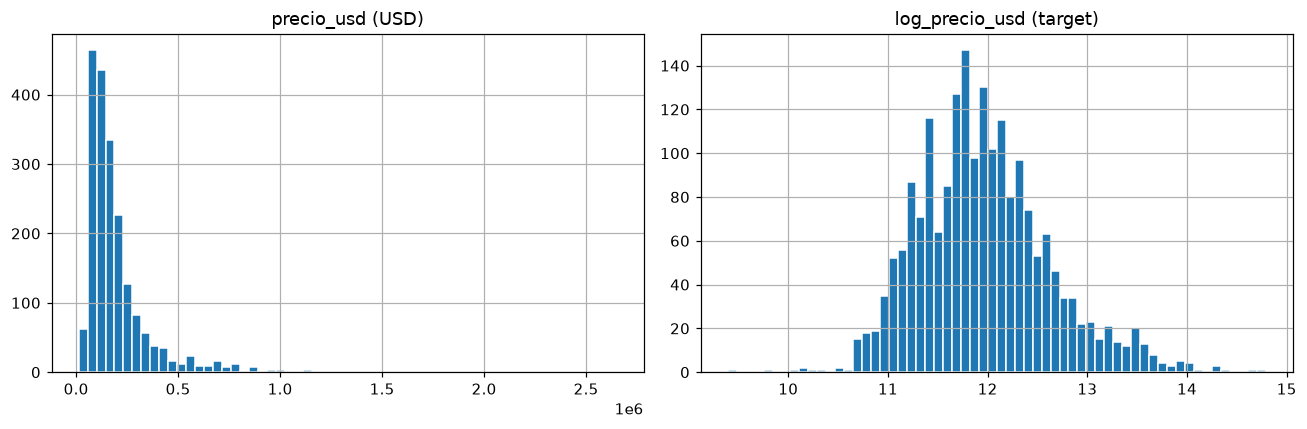

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

matriz["precio_usd"].hist(bins=60, ax=axes[0], edgecolor="white")
axes[0].set_title("precio_usd (USD)")

matriz["log_precio_usd"].hist(bins=60, ax=axes[1], edgecolor="white")
axes[1].set_title("log_precio_usd (target)")

plt.tight_layout()
plt.show()

## 3. Verificación de la codificación ordinal

El código ordinal debe respetar el orden de mediana de precio: a mayor código,
mayor precio mediano. La verificación descarta el código -1 (desconocido/NaN).


In [6]:
precio_mediano_por_codigo = (
    matriz[matriz["barrio_ordinal"] >= 0].groupby("barrio_ordinal")["precio_usd"].median()
)

print(precio_mediano_por_codigo.round(0).astype(int).to_string())

assert precio_mediano_por_codigo.is_monotonic_increasing
print("\nLa mediana de precio crece con barrio_ordinal: OK")

barrio_ordinal
0      54500
1      57000
2      75000
3      75300
4      81000
5      86000
6      89500
7      90000
8      90625
9      92360
10     95000
11     96500
12    105000
13    106500
14    110000
15    115000
16    115500
17    119500
18    123300
19    125000
20    127714
21    130450
22    131500
23    136000
24    139900
25    145000
26    145000
27    147000
28    148500
29    149800
30    154000
31    158000
32    168000
33    170000
34    175000
35    175000
36    175550
37    182000
38    190000
39    193500
40    210000
41    228500
42    245000
43    730000

La mediana de precio crece con barrio_ordinal: OK


## 4. Split train / val / test

`pl.dividir_train_val_test` parte la matriz en 80 % train, 10 % val y 10 % test con
`random_state` fijo para reproducibilidad. En la fase de modelado, los ajustes
(orden ordinal e imputador) se aprenderán **solo** sobre train y se reaplicarán a
val/test usando la API `crear_*` / `aplicar_*`, para no filtrar información.


In [7]:
train, val, test = pl.dividir_train_val_test(matriz, random_state=42)

print(f"Train: {len(train):,} ({len(train) / len(matriz):.0%})")
print(f"Val:   {len(val):,} ({len(val) / len(matriz):.0%})")
print(f"Test:  {len(test):,} ({len(test) / len(matriz):.0%})")

Train: 1,599 (80%)
Val:   200 (10%)
Test:  200 (10%)


In [8]:
# Los tres splits comparten el mismo esquema.
for nombre, sub in [("train", train), ("val", val), ("test", test)]:
    assert list(sub.columns) == list(train.columns)
    print(f"{nombre}: {sub.shape}")

print("\nEjemplo (train):")
print(train.head(3).round(2).to_string())

train: (1599, 16)
val: (200, 16)
test: (200, 16)

Ejemplo (train):
      superficie_cubierta  ambientes  dormitorios  banos  antiguedad  precio_usd  expensas_usd  expensas_informado  superficie_cubierta_informado  ambientes_informado  dormitorios_informado  banos_informado  antiguedad_informado  log_precio_usd  barrio_ordinal  tipo_propiedad_ordinal
240                  62.0        3.0          2.0    1.0        40.0    235999.0        129.87                   0                              1                    1                      1                0                     0           12.37              37                       1
814                  92.0        4.0          3.0    1.0        16.0    225000.0        129.87                   0                              1                    1                      1                0                     1           12.32              34                       1
1830                170.0        5.0          3.0    1.0        55.0    265000

## 5. Guardar el artefacto

In [9]:
matriz.to_csv(RUTA_FEATURES, index=False)
print(f"Matriz guardada en: {RUTA_FEATURES.resolve()}")

Matriz guardada en: C:\Users\Manaus\PROYECTOS\predictor_propiedades\data\processed\propiedades_argenprop_features.csv
